# Netflix Dataset — Exploratory Data Analysis
**Internship:** CodeAlpha — Data Analytics (Task 2 & 3)

**Author:** Faiz Ali

**Tools:** Python, Pandas, Matplotlib, Seaborn

---
## Objective
Perform a complete exploratory data analysis on the Netflix Movies and TV Shows dataset to uncover trends, patterns, and insights about Netflix content.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2 — Load Dataset

In [2]:
# Load the dataset
# Make sure netflix_titles.csv is in the same folder as this notebook
df = pd.read_csv('netflix_titles.csv')

print('Dataset loaded!')
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded!
Shape: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 3 — Understand the Data

In [3]:
# Column names and data types
print('=== Column Info ===')
print(df.dtypes)
print()

# Basic statistics
print('=== Basic Statistics ===')
df.describe(include='all')

=== Column Info ===
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

=== Basic Statistics ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [4]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
            Missing Count  Missing %
director             2634      29.91
cast                  825       9.37
country               831       9.44
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


## Step 4 — Data Cleaning

In [5]:
# 1. Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

# 2. Drop rows where date_added is missing (very few rows)
df.dropna(subset=['date_added'], inplace=True)

# 3. Clean date_added column — convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# 4. Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')

# 5. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed: {before - after}')

# 6. Reset index
df.reset_index(drop=True, inplace=True)

print(f'\nClean dataset shape: {df.shape}')
print('Data cleaning complete!')

Duplicates removed: 0

Clean dataset shape: (8797, 15)
Data cleaning complete!


## Step 5 — Analysis & Visualization
### 5.1 — Movies vs TV Shows Distribution

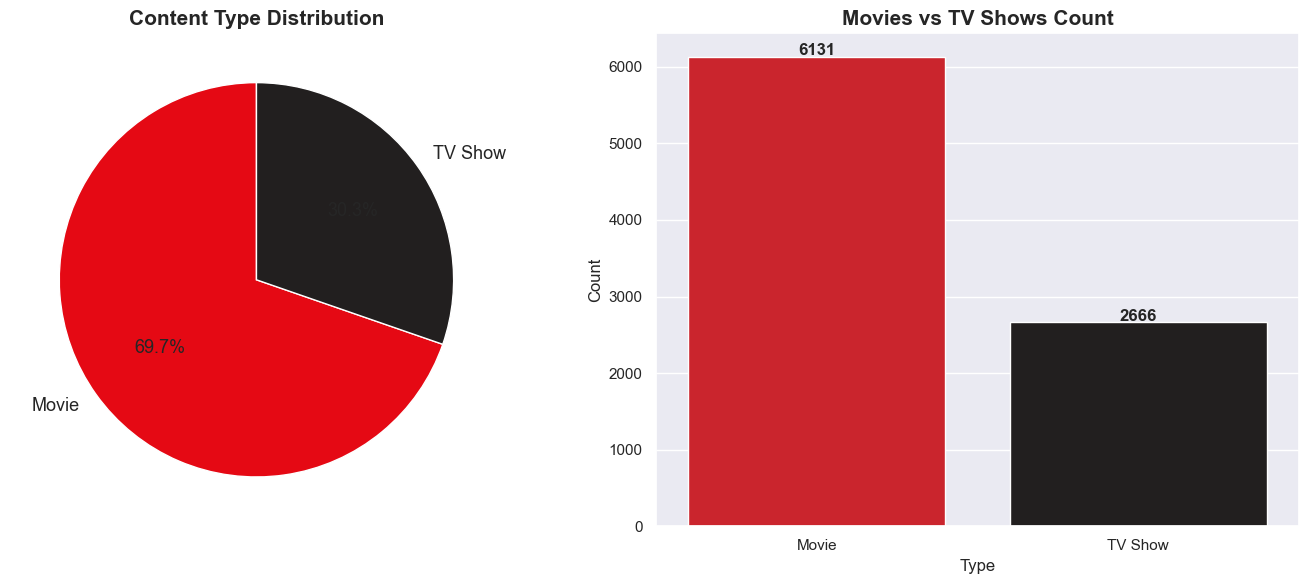


Insight: Netflix has 6131 Movies and 2666 TV Shows


In [6]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#E50914', '#221F1F']
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Content Type Distribution', fontsize=15, fontweight='bold')

# Bar chart
sns.barplot(x=type_counts.index, y=type_counts.values, palette=['#E50914', '#221F1F'], ax=axes[1])
axes[1].set_title('Movies vs TV Shows Count', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('01_movies_vs_tvshows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nInsight: Netflix has {type_counts["Movie"]} Movies and {type_counts["TV Show"]} TV Shows')

### 5.2 — Content Added Per Year

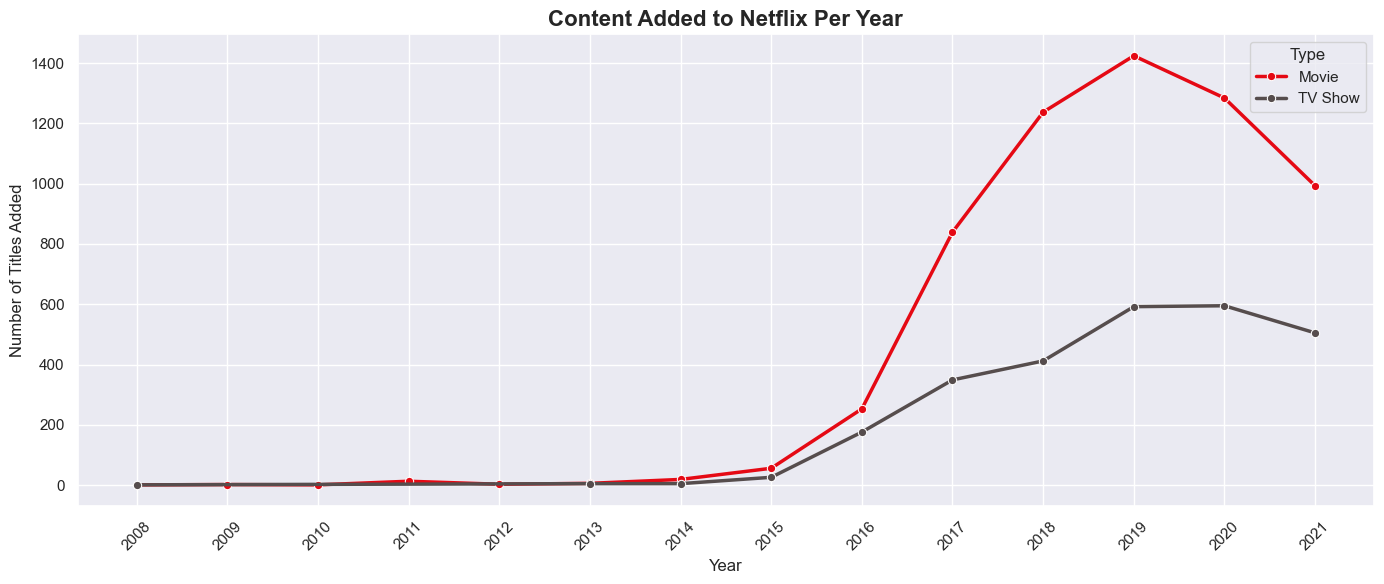

Insight: Netflix content additions grew rapidly from 2015 to 2019, then slightly declined post-2020 (Covid impact)


In [7]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly, x='year_added', y='count', hue='type',
             marker='o', linewidth=2.5, palette=['#E50914', '#564d4d'])
plt.title('Content Added to Netflix Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type')
plt.xticks(yearly['year_added'].unique(), rotation=45)
plt.tight_layout()
plt.savefig('02_content_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Netflix content additions grew rapidly from 2015 to 2019, then slightly declined post-2020 (Covid impact)')

### 5.3 — Top 10 Countries Producing Content

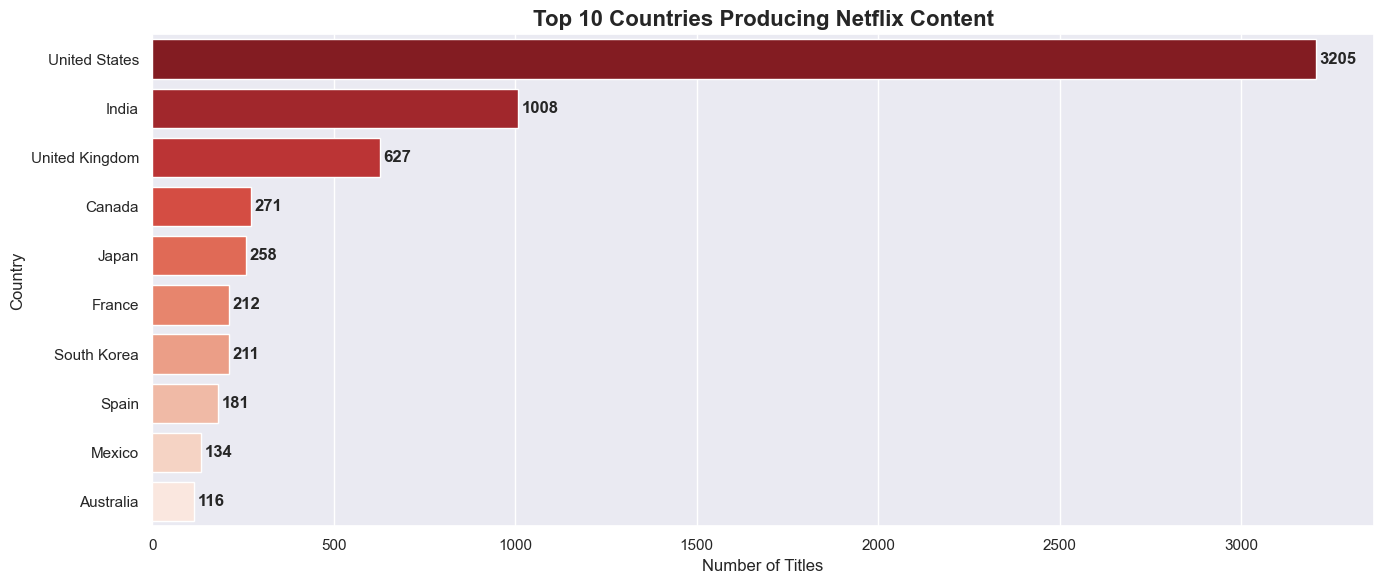

Insight: United States leads Netflix content production with 3205 titles


In [8]:
# Some rows have multiple countries — take the first one
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown')

top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

plt.figure(figsize=(14, 6))
bars = sns.barplot(x=top_countries.values, y=top_countries.index,
                   palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
for i, v in enumerate(top_countries.values):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('03_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: {top_countries.index[0]} leads Netflix content production with {top_countries.values[0]} titles')

### 5.4 — Top 10 Genres

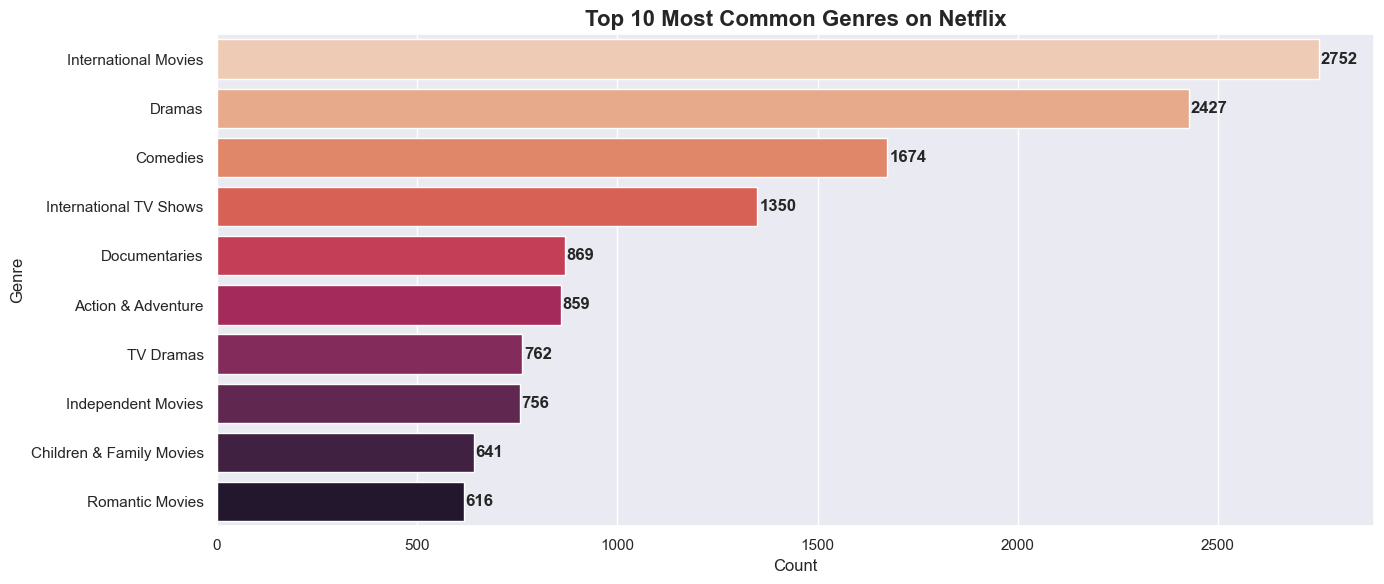

Insight: "International Movies" is the most common genre on Netflix


In [9]:
# listed_in contains multiple genres — split and explode
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket_r')
plt.title('Top 10 Most Common Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Genre')
for i, v in enumerate(top_genres.values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('04_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: "{top_genres.index[0]}" is the most common genre on Netflix')

### 5.5 — Content Ratings Distribution

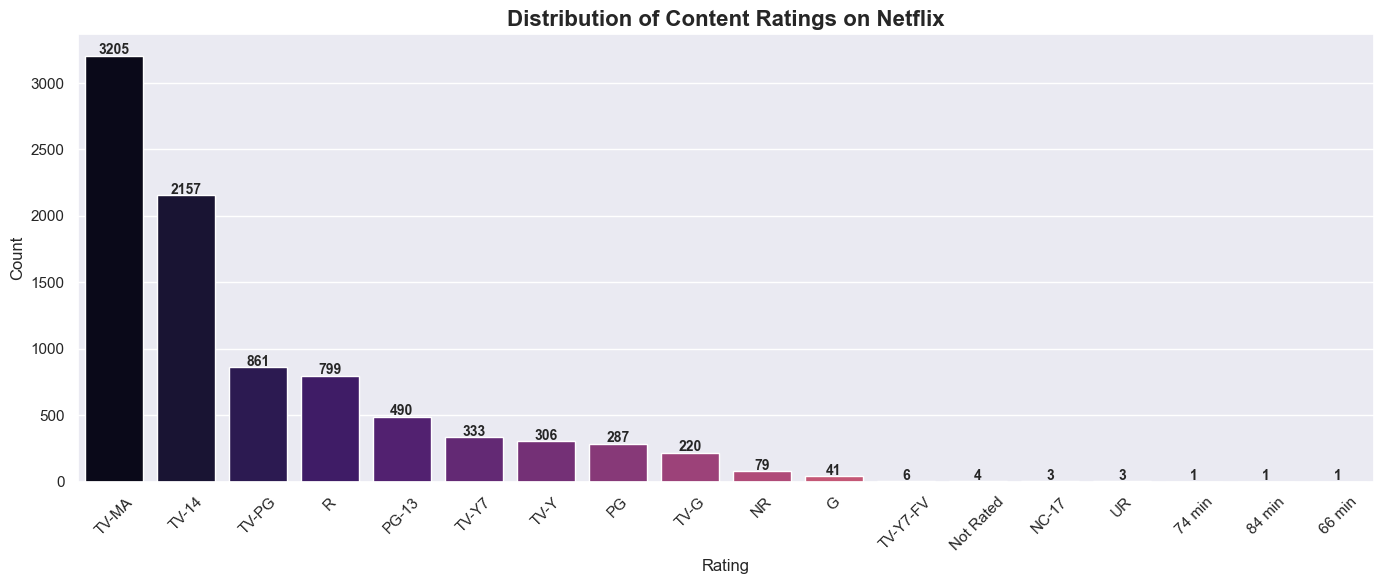

Insight: "TV-MA" is the most common content rating on Netflix


In [10]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(14, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='magma')
plt.title('Distribution of Content Ratings on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('05_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: "{rating_counts.index[0]}" is the most common content rating on Netflix')

### 5.6 — Which Month Does Netflix Add Most Content?

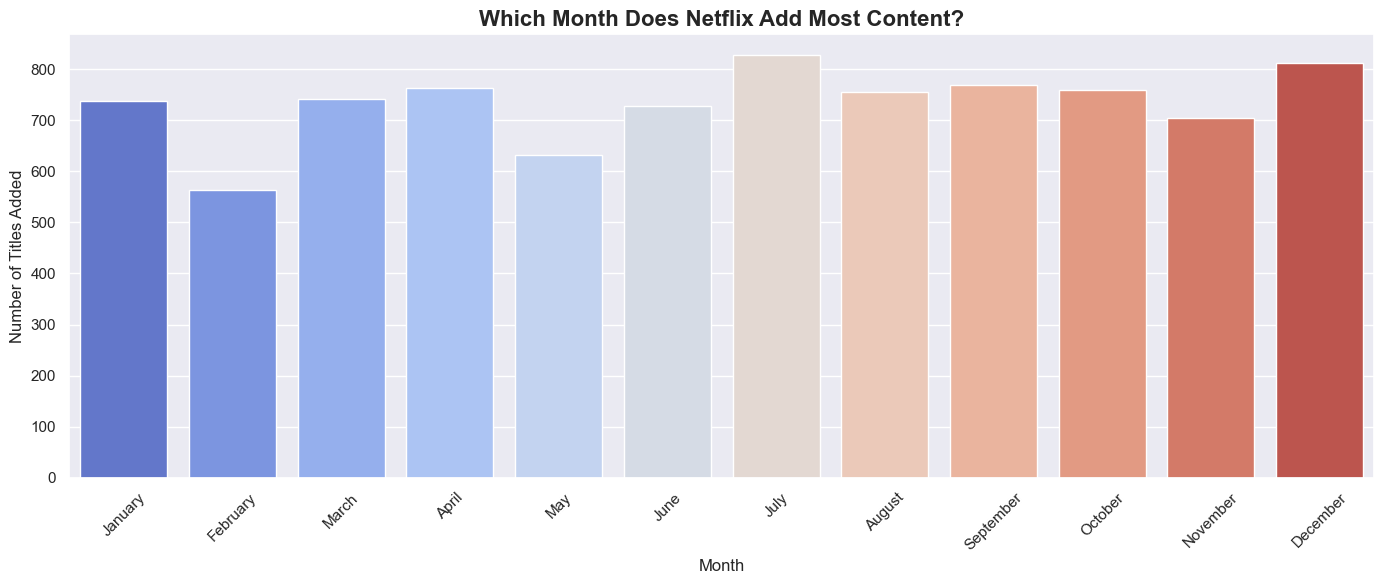

Insight: Netflix adds the most content in July every year


In [11]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df['month_name'].value_counts().reindex(month_order)

plt.figure(figsize=(14, 6))
sns.barplot(x=monthly.index, y=monthly.values, palette='coolwarm')
plt.title('Which Month Does Netflix Add Most Content?', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('06_monthly_additions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: Netflix adds the most content in {monthly.idxmax()} every year')

### 5.7 — Movies: Release Year Distribution

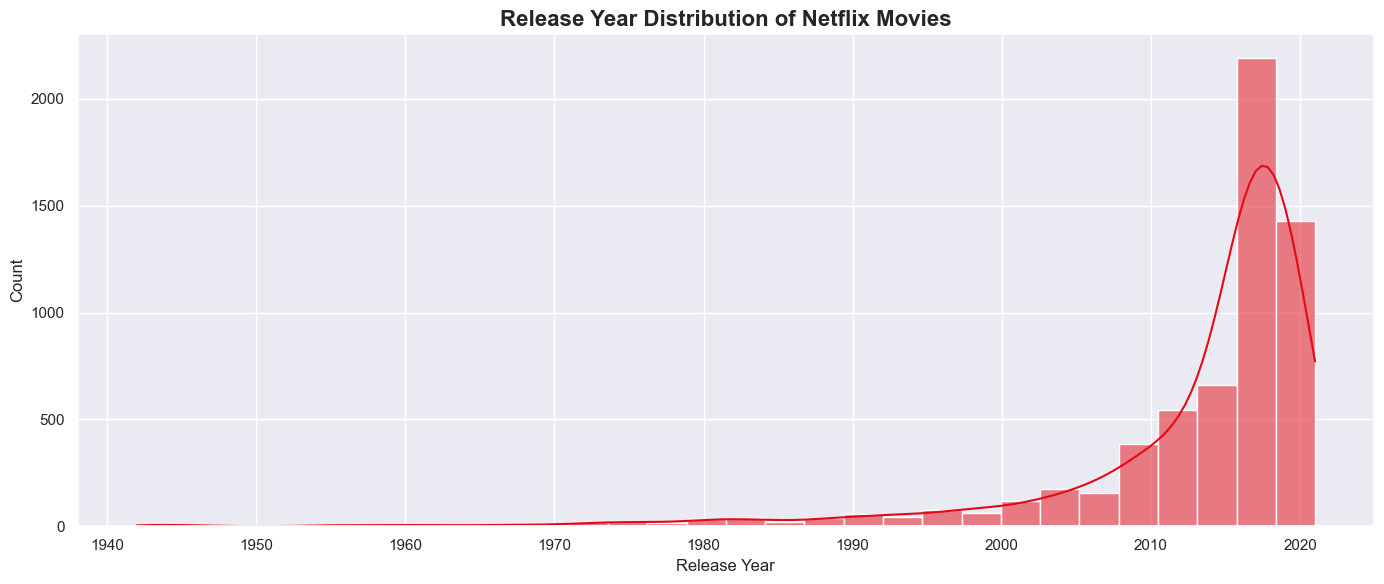

Insight: Most Netflix movies are recent productions from 2010 onwards


In [12]:
movies_df = df[df['type'] == 'Movie']

plt.figure(figsize=(14, 6))
sns.histplot(movies_df['release_year'], bins=30, color='#E50914', kde=True)
plt.title('Release Year Distribution of Netflix Movies', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('07_movie_release_years.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Most Netflix movies are recent productions from 2010 onwards')

### 5.8 — Heatmap: Content Added by Year and Month

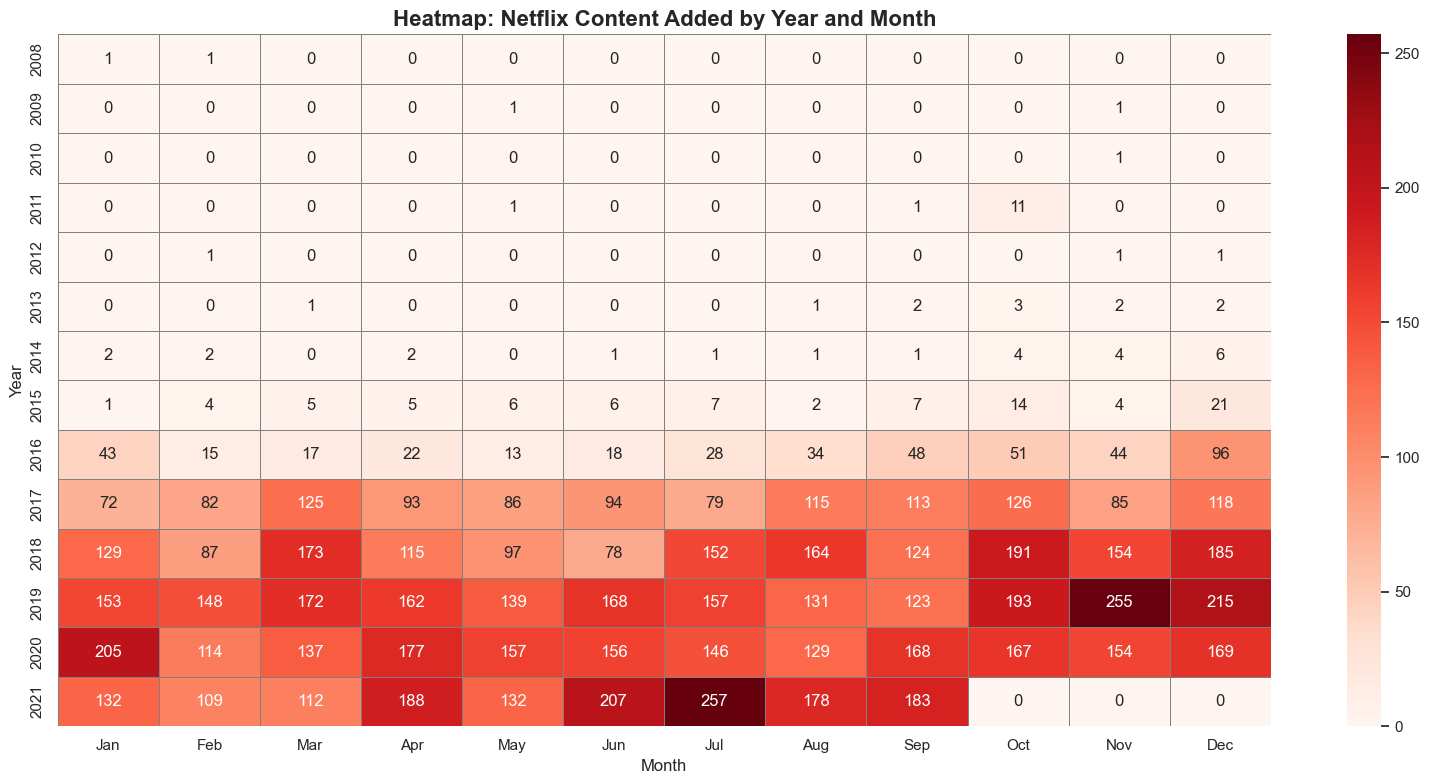

Insight: Clear peak periods visible — Netflix strategically adds content in specific months


In [13]:
heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'][:len(heatmap_data.columns)]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, linecolor='gray')
plt.title('Heatmap: Netflix Content Added by Year and Month', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('08_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Clear peak periods visible — Netflix strategically adds content in specific months')

## Step 6 — Summary of Key Findings

In [14]:
print('=' * 55)
print('     NETFLIX EDA — KEY FINDINGS SUMMARY')
print('=' * 55)
print(f'Total titles analysed    : {len(df)}')
print(f'Total Movies             : {len(df[df["type"]=="Movie"])}')
print(f'Total TV Shows           : {len(df[df["type"]=="TV Show"])}')
print(f'Top producing country    : {df["primary_country"].value_counts().index[0]}')
print(f'Most common genre        : {genres.value_counts().index[0]}')
print(f'Most common rating       : {df["rating"].value_counts().index[0]}')
print(f'Peak content month       : {monthly.idxmax()}')
print(f'Year with most content   : {df["year_added"].value_counts().index[0]}')
print('=' * 55)
print('\nEDA Complete! All charts saved as PNG files.')

     NETFLIX EDA — KEY FINDINGS SUMMARY
Total titles analysed    : 8797
Total Movies             : 6131
Total TV Shows           : 2666
Top producing country    : United States
Most common genre        : International Movies
Most common rating       : TV-MA
Peak content month       : July
Year with most content   : 2019

EDA Complete! All charts saved as PNG files.


---
## Conclusion

This exploratory data analysis of the Netflix dataset revealed several key insights:

- **Movies dominate** Netflix's content library compared to TV Shows
- **The United States** is the largest contributor of Netflix content globally
- Netflix experienced **rapid content growth** between 2015–2019
- **International Movies and Dramas** are the most popular genres
- Netflix strategically adds the most content in **specific months** of the year
- The majority of content carries a **TV-MA or TV-14 rating**, indicating adult-oriented programming

---
*Project by Faiz Ali | CodeAlpha Data Analytics Internship | GitHub: Faizalik1*